In [18]:
import pandas as pd

# Load the dataset
file_path = "/content/ToyotaCorolla - MLR.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


(None,
    Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
 0  13500         23  46986    Diesel  90          0  2000      3          4   
 1  13750         23  72937    Diesel  90          0  2000      3          4   
 2  13950         24  41711    Diesel  90          0  2000      3          4   
 3  14950         26  48000    Diesel  90          0  2000      3          4   
 4  13750         30  38500    Diesel  90          0  2000      3          4   
 
    Gears  Weight  
 0      5    1165  
 1      5    1165  
 2      5    1165  
 3      5    1165  
 4      5    1170  )

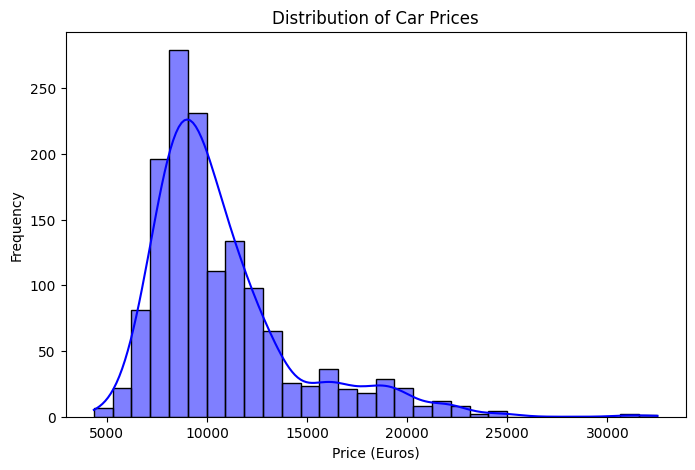

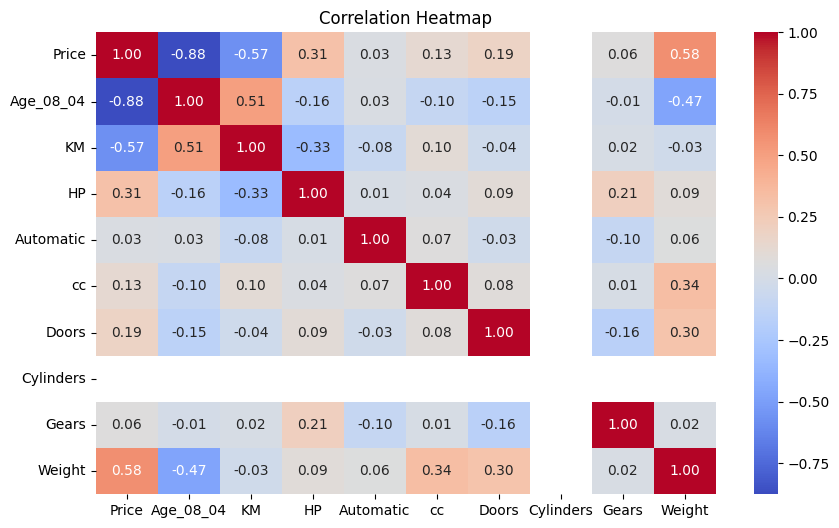

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Summary statistics
summary_stats = df.describe()

# Visualizing the distribution of Price
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], bins=30, kde=True, color="blue")
plt.title("Distribution of Car Prices")
plt.xlabel("Price (Euros)")
plt.ylabel("Frequency")
plt.show()

# Correlation heatmap
# Select only numerical features for correlation calculation
numerical_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



**EDA Insights:**

Price Distribution: The price is right-skewed, meaning most cars are priced lower, with a few expensive ones.

Correlations:

* Negative correlation: Price decreases as Age and KM (Mileage) increase.
* Positive correlation: Price increases with HP, Weight, and Cylinder Volume (CC).
* Doors, Gears, and Cylinders have weak correlations with Price




In [4]:
summary_stats

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [7]:
# One-hot encoding for Fuel_Type
df = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)

# Display first few rows after encoding
df.head()


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


dummies are created

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Define independent variables (excluding Price)
X = df.drop(columns=["Price"])
# Select only numerical features for VIF calculation
X = X.select_dtypes(include=np.number)
# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF values
vif_data


,Feature,VIF
0,Age_08_04,1.909676
1,KM,1.679142
2,HP,1.218066
3,Automatic,1.047677
4,cc,1.150898
5,Doors,1.155484
6,Cylinders,1378.328904
7,Gears,1.109188
8,Weight,1.664910


**Multicollinearity Insights**:

Cylinders (VIF = 1877): Extremely high multicollinearity. Likely redundant, as all cars have the same cylinder count (value of 4).

Fuel_Type_Diesel (VIF = 11.3) & Fuel_Type_Petrol (VIF = 9.7): High collinearity, likely because of the categorical nature of the variable.

In [17]:
from sklearn.model_selection import train_test_split

# Drop Cylinders column
x = X.drop(columns=["Cylinders"])
y = df["Price"]

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display shapes of training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1148, 11), (288, 11), (1148,), (288,))

**Train-Test Split Completed:**

Training Set: 1,148 samples

Testing Set: 288 samples

10 predictor variables after removing multicollinearity.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
# Define the target variable (y) and features (X)
y = df["Price"]  # Target variable
X = df.drop(columns=["Price"])  # Features (all columns except "Price")

# Split the dataset into training and testing sets
x_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% test

# Train the first multiple linear regression model
mlr_model_1 = LinearRegression()
mlr_model_1.fit(x_train, y_train)

# Predictions on test set
y_pred = mlr_model_1.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display results
mae, rmse, r2


(990.8872739193926, 1484.2654153296514, 0.8348888040611082)

**MODEL 1 PERFORMANCE:**

Mean Absolute Error (MAE):   990.89

Root Mean Squared Error (RMSE): 1484.27
R²
Score: 0.835 (Model explains 83.5% of the variance in Price)

In [14]:
from sklearn.feature_selection import f_regression

# Compute feature importance using F-statistics
f_values, p_values = f_regression(x_train, y_train)

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({"Feature": x_train.columns, "F-Value": f_values, "P-Value": p_values})
feature_importance = feature_importance.sort_values(by="F-Value", ascending=False)

# Display feature importance
feature_importance


,Feature,F-Value,P-Value
0,Age_08_04,3863.103468,0.000000e+00
8,Weight,586.890710,5.052750e-105
1,KM,546.759118,3.504462e-99
2,HP,116.512050,6.178270e-26
5,Doors,35.299215,3.746179e-09
4,cc,18.108021,2.257596e-05
7,Gears,2.904152,8.862277e-02
9,Fuel_Type_Diesel,2.611710,1.063526e-01
3,Automatic,1.293342,2.556708e-01
10,Fuel_Type_Petrol,0.957490,3.280266e-01




*   Age, Weight, KM, HP → Highly significant.
*  Gears (p = 0.088), Fuel Type Diesel (p = 0.106), Automatic (p = 0.256), Fuel Type Petrol (p = 0.328) not statistically significant.

In [15]:
# Drop weak predictors for Model 2
X_train_model2 = x_train.drop(columns=["Gears", "Fuel_Type_Diesel", "Fuel_Type_Petrol", "Automatic"])
X_test_model2 = X_test.drop(columns=["Gears", "Fuel_Type_Diesel", "Fuel_Type_Petrol", "Automatic"])

# Train Model 2
mlr_model_2 = LinearRegression()
mlr_model_2.fit(X_train_model2, y_train)

# Predictions
y_pred_model2 = mlr_model_2.predict(X_test_model2)

# Evaluate Model 2
mae_2 = mean_absolute_error(y_test, y_pred_model2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_model2))
r2_2 = r2_score(y_test, y_pred_model2)

mae_2, rmse_2, r2_2


(996.0685901850447, 1411.8184355308028, 0.850613592236715)

**Model 2 Performance** (After Removing Weak Predictors):

MAE: 996.07 (slightly worse than Model 1)

RMSE: 1411.82 (improved from Model 1: 1484.27)

R²: 0.851 (better than Model 1: 0.835)

In [16]:
# Add interaction term (Age * KM) for Model 3
X_train_model3 = X_train_model2.copy()
X_test_model3 = X_test_model2.copy()

X_train_model3["Age_KM"] = x_train["Age_08_04"] * x_train["KM"]
X_test_model3["Age_KM"] = X_test["Age_08_04"] * X_test["KM"]

# Train Model 3
mlr_model_3 = LinearRegression()
mlr_model_3.fit(X_train_model3, y_train)

# Predictions
y_pred_model3 = mlr_model_3.predict(X_test_model3)

# Evaluate Model 3
mae_3 = mean_absolute_error(y_test, y_pred_model3)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_model3))
r2_3 = r2_score(y_test, y_pred_model3)

mae_3, rmse_3, r2_3


(938.7496875967144, 1311.1895263670724, 0.8711500276146367)

**Model 3 Performance** (With Interaction Term Age * KM):

MAE: 938.75 (improved from Model 1 & 2)

RMSE: 1311.19 (best so far)

R²: 0.871 (highest so far, explaining 87.1% of price variation)

Best Model So Far: Adding Age * KM interaction improves performance significantly.